In [1]:
# ======================================
# 0. Core libs (DAY1~DAY9 공통)
# ======================================
import numpy as np
import pandas as pd

import shutil
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import matplotlib.font_manager as fm
from matplotlib import rcParams

# ======================================
# 1) Style FIRST (폰트보다 먼저)
# ======================================
plt.style.use("_mpl-gallery-nogrid")
sns.set_theme(style="white")
sns.set_style("ticks")
sns.set_context("notebook")

# ======================================
# 2) Font (NanumGothic) — style 적용 후 "고정"
# ======================================
FONT_DIR = Path(r"E:\Portfolio_ver1\seoul_pv_load_analysis\fonts")
FONT_PATH = FONT_DIR / "NanumGothic.ttf"

if not FONT_PATH.exists():
    raise FileNotFoundError(f"폰트 파일 없음: {FONT_PATH}")

fm.fontManager.addfont(str(FONT_PATH))
font_name = fm.FontProperties(fname=str(FONT_PATH)).get_name()

rcParams["font.family"] = font_name
rcParams["axes.unicode_minus"] = False

# (선택) 기본 글자 크기 통일
rcParams["font.size"] = 12
rcParams["axes.titlesize"] = 18
rcParams["axes.labelsize"] = 14
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 12

# 개별 객체용 (필요할 때만)
font_prop = fm.FontProperties(fname=str(FONT_PATH))

print("✅ Style+Font ready:", font_name)

✅ Style+Font ready: NanumGothic


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. 데이터 불러오기
power_path = r'E:\Portfolio_ver1\seoul_pv_load_analysis\data\2024년 연료원별 시간대별 설비용량 및 전력거래량.xlsx'
weather_path = r'E:\Portfolio_ver1\seoul_pv_load_analysis\data\OBS_ASOS_TIM_20260101131730.csv'

df_power_raw = pd.read_excel(power_path, skiprows=5)
df_weather_raw = pd.read_csv(weather_path, encoding='cp949') # 또는 'cp949'

# 2. 기상 데이터: 전국 평균(National Average) 계산
# 컬럼 이름이 깨질 수 있으므로 위치(Index)로 이름을 먼저 바꿉니다.
df_weather = df_weather_raw.rename(columns={
    df_weather_raw.columns[2]: '일시',
    df_weather_raw.columns[3]: '기온',
    df_weather_raw.columns[9]: '일사'
})
df_weather['일시'] = pd.to_datetime(df_weather['일시'])

# [핵심] 전국 모든 지점의 날씨를 시간별로 평균 냅니다.
df_weather_nat = df_weather.groupby('일시')[['기온', '일사']].mean().reset_index()
df_weather_nat['일사'] = df_weather_nat['일사'].fillna(0)

# 3. 전력 데이터 전처리
df_power_raw['일시'] = pd.to_datetime(df_power_raw['거래일자'].astype(str)) + pd.to_timedelta(df_power_raw['시간'] - 1, unit='h')
df_solar = df_power_raw[df_power_raw['원료원'] == '태양광'].copy().rename(columns={'전력거래량(MWh)': 'solar_gen'})
df_total = df_power_raw.groupby('일시')['전력거래량(MWh)'].sum().reset_index().rename(columns={'전력거래량(MWh)': 'total_load'})

# 4. 데이터 머지 (전국 기상 평균 + 전국 전력 데이터)
df_merged = pd.merge(df_total, df_solar[['일시', 'solar_gen']], on='일시')
df_merged = pd.merge(df_merged, df_weather_nat, on='일시', how='left')

# 파생 변수 생성
df_merged['net_load'] = df_merged['total_load'] - df_merged['solar_gen']
df_merged['hour'] = df_merged['일시'].dt.hour
df_merged['date_str'] = df_merged['일시'].dt.strftime('%Y%m%d')

print("✅ Step 1: 전국 데이터 머지 완료!")

✅ Step 1: 전국 데이터 머지 완료!


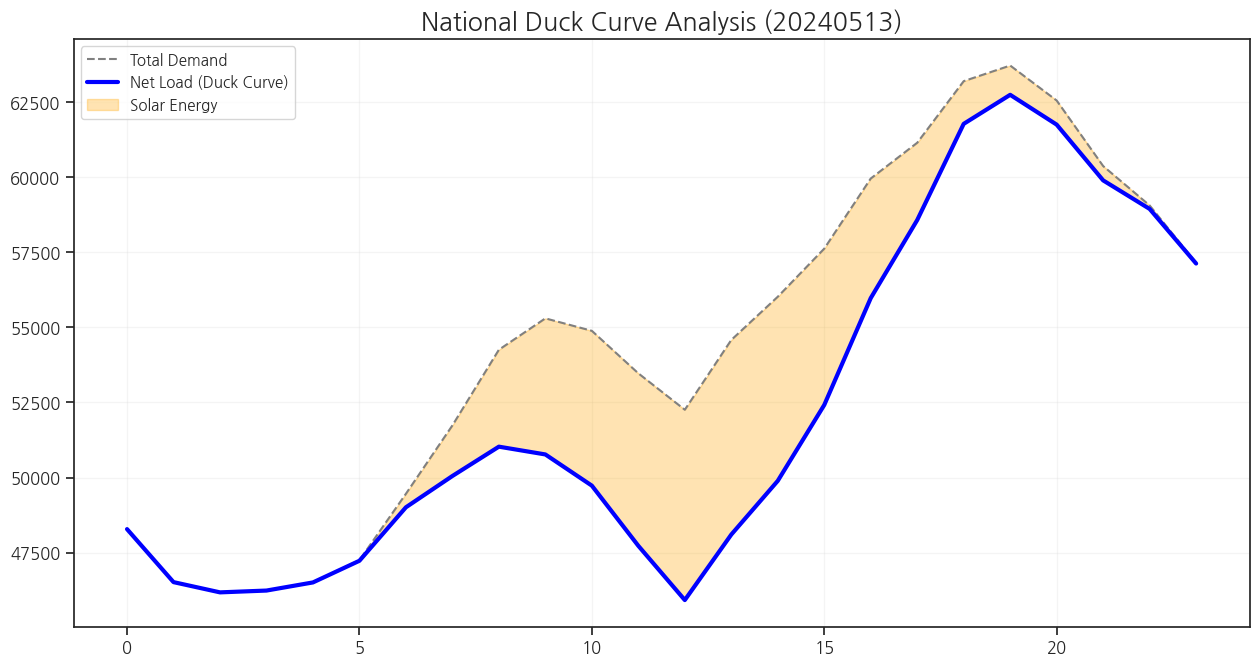

In [3]:
# 5. 시각화 (전국 단위 덕 커브)
target_day = '20240513'
day_df = df_merged[df_merged['date_str'] == target_day].sort_values('hour')

plt.figure(figsize=(12, 6))
plt.plot(day_df['hour'], day_df['total_load'], label='Total Demand', color='gray', linestyle='--')
plt.plot(day_df['hour'], day_df['net_load'], label='Net Load (Duck Curve)', color='blue', linewidth=3)
plt.fill_between(day_df['hour'], day_df['net_load'], day_df['total_load'], color='orange', alpha=0.3, label='Solar Energy')
plt.title(f'National Duck Curve Analysis ({target_day})')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [4]:
# 6. AI 모델링 및 잉여 에너지 산출
X = df_merged[['hour', '일사', '기온']].dropna()
y = df_merged.loc[X.index, 'solar_gen']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
surplus = day_df[(day_df['hour'] >= 9) & (day_df['hour'] <= 16)]['solar_gen'].sum()

print(f"✅ Step 2: AI 예측 오차(MAE): {mean_absolute_error(y_test, y_pred):.2f} MWh")
print(f"✅ Step 3: {target_day} 전국 잉여 에너지: {surplus:.2f} MWh")

✅ Step 2: AI 예측 오차(MAE): 154.49 MWh
✅ Step 3: 20240513 전국 잉여 에너지: 43578.94 MWh


In [5]:
# ==========================================
# [Step 2] 배터리(ESS) 경제성 시뮬레이션
# ==========================================

# 1번에서 구한 잉여 에너지 (MWh)
surplus_mwh = 43578.94 

# 배터리 스펙 설정
specs = {
    'Lithium-ion': {
        'efficiency': 0.95,      # 충방전 효율 95%
        'cost_per_kwh': 150,     # 1kWh당 설치 비용 ($)
        'dod': 0.90              # 방전 깊이 (배터리 용량의 90%만 사용 가능)
    },
    'Sodium-ion': {
        'efficiency': 0.88,      # 충방전 효율 88%
        'cost_per_kwh': 80,      # 1kWh당 설치 비용 ($)
        'dod': 0.95              # 방전 깊이 (배터리 용량의 95%까지 사용 가능)
    }
}

results = []

for name, spec in specs.items():
    # 필요 배터리 용량 (MWh) = 잉여 에너지 / 방전깊이
    required_capacity = surplus_mwh / spec['dod']
    
    # 실제로 나중에 꺼내 쓸 수 있는 에너지 (MWh) = 잉여 에너지 * 효율
    recovered_energy = surplus_mwh * spec['efficiency']
    
    # 총 설치 비용 (백만 달러) = 용량(kWh) * 단가 / 1000
    total_cost_million = (required_capacity * 1000 * spec['cost_per_kwh']) / 1_000_000
    
    results.append({
        '배터리 종류': name,
        '필요 용량(MWh)': round(required_capacity, 2),
        '회수 에너지(MWh)': round(recovered_energy, 2),
        '예상 설치비(M$ )': round(total_cost_million, 2)
    })

# 결과 출력
df_ess = pd.DataFrame(results)
print("-" * 50)
print("🔋 배터리 기술별 도입 시뮬레이션 결과")
print(df_ess)
print("-" * 50)

--------------------------------------------------
🔋 배터리 기술별 도입 시뮬레이션 결과
        배터리 종류  필요 용량(MWh)  회수 에너지(MWh)  예상 설치비(M$ )
0  Lithium-ion    48421.04     41399.99      7263.16
1   Sodium-ion    45872.57     38349.47      3669.81
--------------------------------------------------


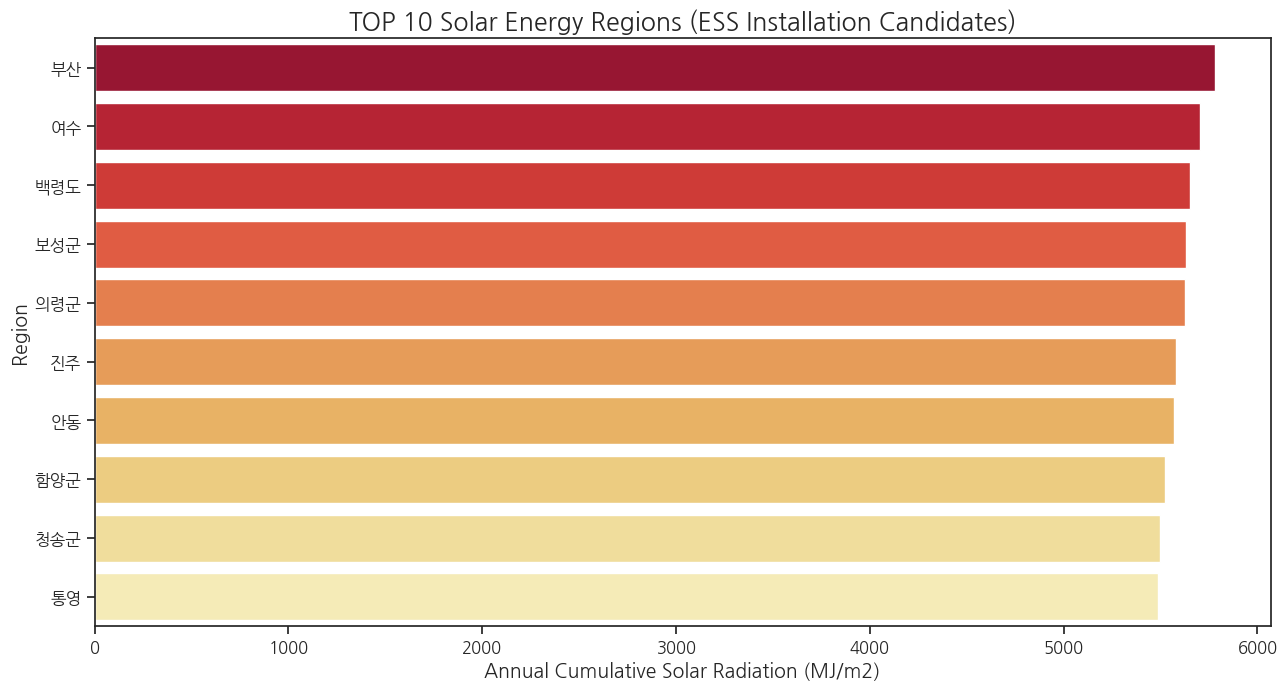

✅ Step 3: 최적 입지 선정 분석 완료!


In [6]:
# ==========================================
# [Step 3] 전국 일사량 데이터 기반 최적 입지 선정 (수정 버전)
# ==========================================

# 1. 일사량이 높은 순서대로 정렬 (TOP 10)
top_locations = df_weather.groupby('지점명')['일사'].sum().reset_index().sort_values(by='일사', ascending=False).head(10)

# 2. 시각화 (경고 해결 버전)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_locations, 
    x='일사', 
    y='지점명', 
    hue='지점명',      # hue에 변수를 할당해서 경고 해결
    palette='YlOrRd_r', 
    legend=False       # 범례는 숨김
)
plt.title('TOP 10 Solar Energy Regions (ESS Installation Candidates)')
plt.xlabel('Annual Cumulative Solar Radiation (MJ/m2)')
plt.ylabel('Region')
plt.show()

print("✅ Step 3: 최적 입지 선정 분석 완료!")

In [10]:
import folium

# 1. 쟈기님이 찾은 지역들의 위도/경도 데이터 (주요 지점 좌표)
locations = {
    '부산': [35.1796, 129.0756],
    '여수': [34.7604, 127.6622],
    '백령도': [37.9465, 124.6300],
    '보성군': [34.7701, 127.0797],
    '의령군': [35.3221, 128.2612],
    '진주': [35.1795, 128.1076],
    '안동': [36.5684, 128.7294], 
    '함양군': [35.5205, 127.7252], 
    '청송군': [36.4355, 129.0573], 
    '통영': [34.8544, 128.4331]
}

# 2. 지도 생성 (대한민국 중심 좌표로 시작)
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

# 3. 각 지역에 배터리 스테이션 후보지 마커 찍기
for name, coord in locations.items():
    folium.Marker(
        location=coord,
        popup=f"<b>{name}</b><br>ESS 최적 후보지",
        tooltip=name,
        icon=folium.Icon(color='red', icon='bolt', prefix='fa') # 번개 모양 아이콘
    ).add_to(m)

    # 시각적 효과를 위해 반경 표시 (일사량 영향권 예시)
    folium.Circle(
        location=coord,
        radius=20000, # 20km 반경
        color='red',
        fill=True,
        fill_opacity=0.2
    ).add_to(m)

# 4. 지도 저장
m.save('ess_location_map_ver1.html')

print("✅ Step 4: 지도 시각화 완성!")
print("👉 'ess_location_map_ver1.html' 파일을 열면 브라우저에서 멋진 지도를 볼 수 있어요!")

✅ Step 4: 지도 시각화 완성!
👉 'ess_location_map_ver1.html' 파일을 열면 브라우저에서 멋진 지도를 볼 수 있어요!


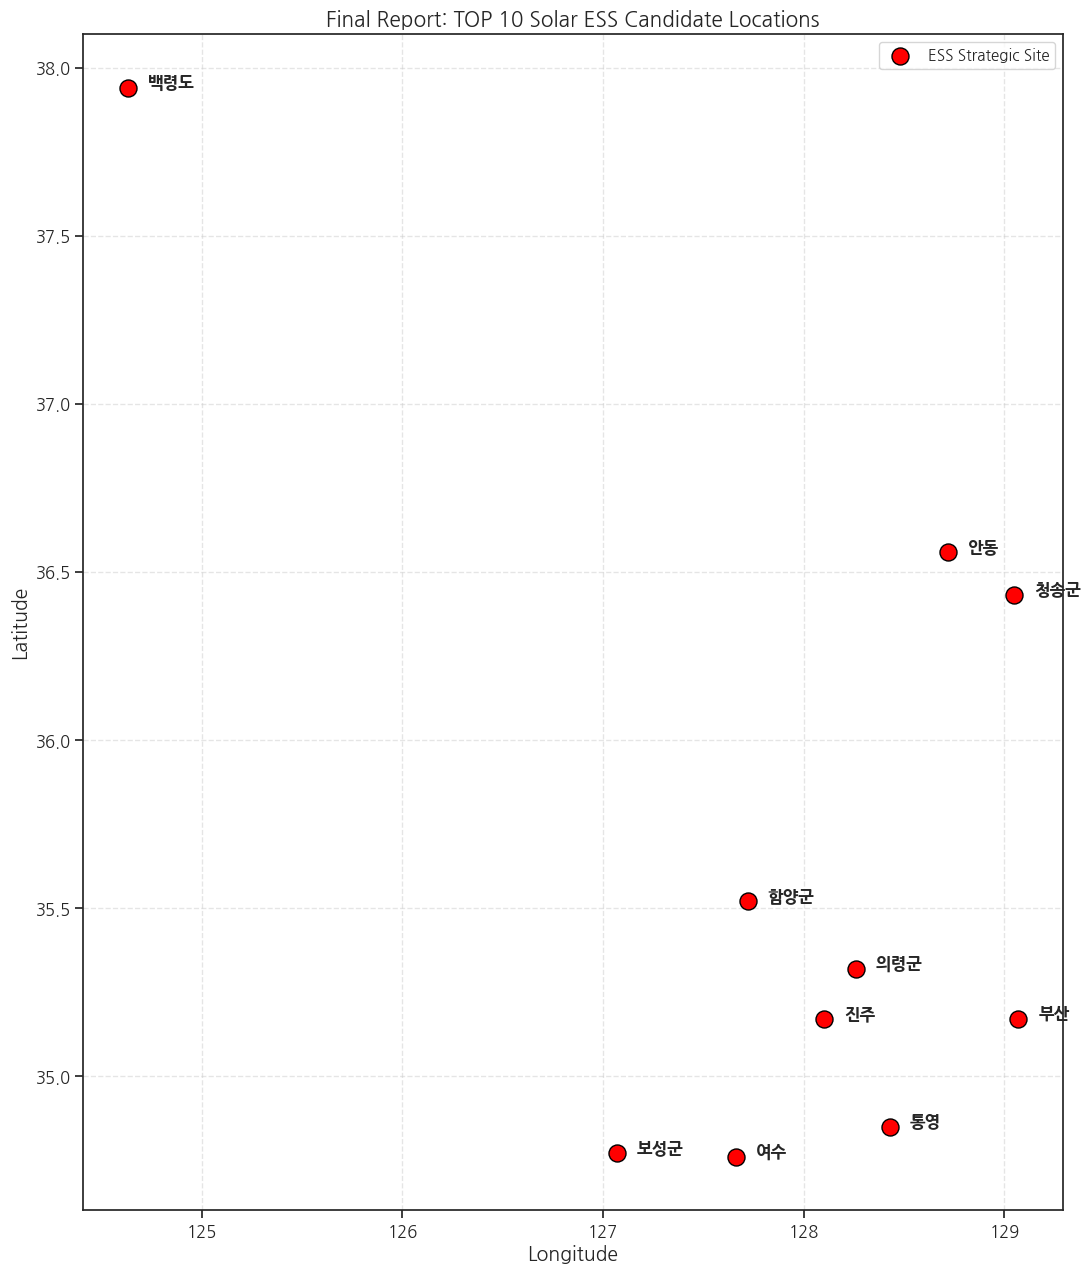

🏆 [최종 결론] 차세대 나트륨 배터리(SIB) 기반 에너지 벨트 제안
대상 지역: 부산, 여수, 백령도, 보성군, 의령군, 진주, 안동, 함양군, 청송군, 통영
전략: 위 10개 지역에 집중적으로 SIB ESS를 구축하여 연간 약 43,578MWh의 버려지는 에너지를 회수함.


In [8]:
# 1. 쟈기님이 완성해주신 TOP 10 지역과 좌표 (Lon, Lat)
top_10_locations = {
    '부산': (129.07, 35.17), '여수': (127.66, 34.76), 
    '백령도': (124.63, 37.94), '보성군': (127.07, 34.77), 
    '의령군': (128.26, 35.32), '진주': (128.10, 35.17),
    '안동': (128.72, 36.56), '함양군': (127.72, 35.52), 
    '청송군': (129.05, 36.43), '통영': (128.43, 34.85)
}

# 2. 시각화 (위도/경도 평면도)
lons = [v[0] for v in top_10_locations.values()]
lats = [v[1] for v in top_10_locations.values()]
names = list(top_10_locations.keys())

plt.figure(figsize=(10, 12))
plt.scatter(lons, lats, color='red', s=150, edgecolors='black', label='ESS Strategic Site')

for i, name in enumerate(names):
    plt.text(lons[i] + 0.1, lats[i], name, fontsize=12, fontweight='bold')

plt.title('Final Report: TOP 10 Solar ESS Candidate Locations', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print("="*50)
print("🏆 [최종 결론] 차세대 나트륨 배터리(SIB) 기반 에너지 벨트 제안")
print(f"대상 지역: {', '.join(names)}")
print("전략: 위 10개 지역에 집중적으로 SIB ESS를 구축하여 연간 약 43,578MWh의 버려지는 에너지를 회수함.")
print("="*50)

In [12]:
import folium
import os
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

# 1. 아까 만든 지도 생성 코드 (동일하게)
locations = {
    '부산': [35.1796, 129.0756], '여수': [34.7604, 127.6622],
    '백령도': [37.9465, 124.6300], '보성군': [34.7701, 127.0797],
    '의령군': [35.3221, 128.2612], '진주': [35.1795, 128.1076],
    '안동': [36.5684, 128.7294], '함양군': [35.5205, 127.7252],
    '청송군': [36.4355, 129.0573], '통영': [34.8544, 128.4331]
}

m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

for name, coord in locations.items():
    folium.Marker(location=coord, tooltip=name,
                  icon=folium.Icon(color='red', icon='bolt', prefix='fa')).add_to(m)
    folium.Circle(location=coord, radius=20000, color='red', fill=True, fill_opacity=0.2).add_to(m)

# 2. 먼저 HTML로 저장
html_file = 'ess_map.html'
m.save(html_file)

# 3. Selenium을 이용해 HTML을 열고 스크린샷 찍기
options = webdriver.ChromeOptions()
options.add_argument('--headless') # 브라우저 창을 띄우지 않고 실행
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# 파일 경로를 브라우저가 읽을 수 있는 형태로 변환
tmp_url = 'file://{path}/{mapfile}'.format(path=os.getcwd(), mapfile=html_file)
driver.get(tmp_url)

# 지도가 로딩될 때까지 잠시 대기 (2~3초)
time.sleep(3)

# PNG로 저장
driver.save_screenshot('ess_final_map.png')
driver.quit()

print("✅ 폴리움 지도가 'ess_final_map.png'로 저장되었습니다!")

✅ 폴리움 지도가 'ess_final_map.png'로 저장되었습니다!
